In [1]:
# Problema: Decidir a qué clientes ofrecer una campaña de retención con cupos limitados, distinguiendo entre quienes tienen mayor riesgo y aquellos cuya decisión puede cambiar por la oferta.
# Un mismo cliente puede tener alto riesgo y bajo efecto causal: no son lo mismo.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["campaign.csv", "synthetic_truth.csv"])

['campaign.csv', 'synthetic_truth.csv']

In [2]:
# Campana sintetica de retencion; cargamos solo los datos observables, sin la verdad causal.

campaign = pd.read_csv(data_dir / "campaign.csv")
display(campaign.head())

,customer_id,tenure_months,recent_transactions,recent_spend,digital_engagement,months_since_last_purchase,annual_fee,customer_value,retention_offer,retained_next_period
0,C0001,47,7,74.87,0.9200,4.93,0,99.90,1,1
1,C0002,27,3,46.05,0.7603,2.26,0,76.84,0,0
2,C0003,52,5,214.51,0.6476,5.48,0,211.61,0,1
3,C0004,42,4,89.45,0.3267,1.36,95,159.06,1,1
4,C0005,7,7,9.61,0.0270,7.00,0,47.69,0,0


In [3]:
# Verificamos los datos observables antes de cualquier modelo causal.

assert len(campaign) == 2000 and campaign.customer_id.is_unique
assert set(campaign.retention_offer.unique()) <= {0, 1}
assert set(campaign.retained_next_period.unique()) <= {0, 1}
assert not ({"true_p0", "true_p1", "true_uplift"} & set(campaign.columns))
treatment_rate = campaign.retention_offer.mean()
assert 0.45 <= treatment_rate <= 0.55
assert campaign.tenure_months.between(1, 60).all()
assert campaign.digital_engagement.between(0, 1).all()
assert campaign.customer_value.gt(0).all()
print(f"{len(campaign)} clientes; oferta de retencion aleatorizada al {treatment_rate:.2%}.")
print("retention_offer fue asignada al azar; ninguna columna de verdad causal esta presente todavia.")

2000 clientes; oferta de retencion aleatorizada al 50.15%.
retention_offer fue asignada al azar; ninguna columna de verdad causal esta presente todavia.


In [4]:
# Separamos entrenamiento y prueba antes de ajustar cualquier modelo causal.

train_idx, test_idx = train_test_split(
    np.arange(len(campaign)),
    test_size=0.4,
    random_state=42,
    stratify=campaign["retention_offer"],
)
assert len(set(train_idx) & set(test_idx)) == 0
train = campaign.iloc[train_idx].reset_index(drop=True)
test = campaign.iloc[test_idx].reset_index(drop=True)
print(
    f"train={len(train)} (control={len(train[train.retention_offer==0])}, "
    f"treated={len(train[train.retention_offer==1])})"
)
print(
    f"test={len(test)} (control={len(test[test.retention_offer==0])}, "
    f"treated={len(test[test.retention_offer==1])})"
)

train=1200 (control=598, treated=602)
test=800 (control=399, treated=401)


In [5]:
# El compromiso digital tiene un efecto no lineal: agregamos su termino cuadratico.

train = train.assign(digital_engagement_squared=train.digital_engagement ** 2)
test = test.assign(digital_engagement_squared=test.digital_engagement ** 2)
FEATURES = [
    "tenure_months", "recent_transactions", "recent_spend",
    "digital_engagement", "digital_engagement_squared",
    "months_since_last_purchase", "annual_fee",
]
print(f"Variables del T-learner ({len(FEATURES)}): {FEATURES}")

Variables del T-learner (7): ['tenure_months', 'recent_transactions', 'recent_spend', 'digital_engagement', 'digital_engagement_squared', 'months_since_last_purchase', 'annual_fee']


In [6]:
# Modelo de control: retencion esperada sin la oferta, ajustado solo con clientes no tratados de entrenamiento.

control_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000, random_state=42))]
)
train_control = train[train.retention_offer == 0]
control_pipeline.fit(train_control[FEATURES], train_control.retained_next_period)
print(f"Modelo de control ajustado con {len(train_control)} clientes no tratados de entrenamiento.")

Modelo de control ajustado con 598 clientes no tratados de entrenamiento.


In [7]:
# Modelo tratado: retencion esperada con la oferta, ajustado solo con clientes tratados de entrenamiento.

treated_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000, random_state=42))]
)
train_treated = train[train.retention_offer == 1]
treated_pipeline.fit(train_treated[FEATURES], train_treated.retained_next_period)
print(f"Modelo tratado ajustado con {len(train_treated)} clientes tratados de entrenamiento.")

Modelo tratado ajustado con 602 clientes tratados de entrenamiento.


In [8]:
# Predecimos ambos resultados potenciales en el conjunto de prueba, nunca visto por los modelos.

p0_hat = control_pipeline.predict_proba(test[FEATURES])[:, 1]
p1_hat = treated_pipeline.predict_proba(test[FEATURES])[:, 1]
uplift_hat = p1_hat - p0_hat
assert np.all((p0_hat >= 0) & (p0_hat <= 1)) and np.all((p1_hat >= 0) & (p1_hat <= 1))
assert np.allclose(uplift_hat, p1_hat - p0_hat)
test = test.assign(p0_hat=p0_hat, p1_hat=p1_hat, uplift_hat=uplift_hat)
display(test[["customer_id", "p0_hat", "p1_hat", "uplift_hat"]].head())

,customer_id,p0_hat,p1_hat,uplift_hat
0,C0160,0.594138,0.748505,0.154367
1,C1295,0.300885,0.258419,-0.042466
2,C1869,0.723746,0.819745,0.095999
3,C1290,0.608832,0.552082,-0.056750
4,C0328,0.318425,0.422726,0.104300


In [9]:
# El riesgo estimado y el efecto causal estimado responden preguntas distintas.

risky_low_uplift = test.loc[
    (test.p0_hat < test.p0_hat.quantile(0.3)) & (test.uplift_hat < test.uplift_hat.quantile(0.3))
]
moderate_high_uplift = test.loc[
    test.p0_hat.between(test.p0_hat.quantile(0.35), test.p0_hat.quantile(0.65))
    & (test.uplift_hat > test.uplift_hat.quantile(0.7))
]
example_columns = ["customer_id", "p0_hat", "p1_hat", "uplift_hat"]
display(risky_low_uplift[example_columns].head(3))
display(moderate_high_uplift[example_columns].head(3))
print("Alto riesgo estimado no implica alto efecto causal estimado; ni al contrario.")
print("Recordatorio: menor p0_hat equivale a mayor riesgo estimado de no retencion.")

,customer_id,p0_hat,p1_hat,uplift_hat
5,C1643,0.212742,0.134404,-0.078338
23,C0676,0.230776,0.211461,-0.019315
50,C1794,0.081225,0.091910,0.010685


,customer_id,p0_hat,p1_hat,uplift_hat
0,C0160,0.594138,0.748505,0.154367
10,C1633,0.393640,0.567150,0.173511
12,C1906,0.371735,0.577678,0.205943


Alto riesgo estimado no implica alto efecto causal estimado; ni al contrario.
Recordatorio: menor p0_hat equivale a mayor riesgo estimado de no retencion.


In [10]:
# El valor incremental convierte el efecto causal estimado en una cifra economica comparable.

intervention_cost = 5.0
incremental_value_hat = uplift_hat * test.customer_value.values - intervention_cost
test = test.assign(incremental_value_hat=incremental_value_hat)
display(test[["customer_id", "uplift_hat", "customer_value", "incremental_value_hat"]].head())

,customer_id,uplift_hat,customer_value,incremental_value_hat
0,C0160,0.154367,140.73,16.724079
1,C1295,-0.042466,282.17,-16.982598
2,C1869,0.095999,198.31,14.037495
3,C1290,-0.056750,179.42,-15.182025
4,C0328,0.104300,177.97,13.562344


In [11]:
# DECISION MODEL
# ---------------------------------------------------------------------
# Set:
#   i in CUSTOMERS
#
# Parameter:
#   value[i]      estimated incremental economic value
#   K             maximum number of offers
#
# Decision variable:
#   x[i] binary
#       1 if customer i receives the offer
#
# Objective:
#   maximize total_incremental_value:
#       sum{i in CUSTOMERS} value[i] * x[i]
#
# Constraints:
#   subject to campaign_capacity:
#       sum{i in CUSTOMERS} x[i] <= K
#
#   subject to positive_value{i in CUSTOMERS}:
#       x[i] = 0 if value[i] <= 0

print("Costo uniforme + valor aditivo por cliente + capacidad de cardinalidad -> ordenar por valor es la solucion exacta.")
print("No se requiere PuLP, HiGHS ni SciPy: el ordenamiento ya es el optimizador exacto.")

Costo uniforme + valor aditivo por cliente + capacidad de cardinalidad -> ordenar por valor es la solucion exacta.
No se requiere PuLP, HiGHS ni SciPy: el ordenamiento ya es el optimizador exacto.


In [12]:
# Funcion de ranking determinista: score principal, con customer_id como desempate estable.

def rank_top_k(df, score_col, ascending, k, positive_only=False):
    ranked = df.sort_values([score_col, "customer_id"], ascending=[ascending, True]).reset_index(drop=True)
    if positive_only:
        ranked = ranked[ranked[score_col] > 0]
    return set(ranked.head(k).customer_id)

print("Funcion de ranking definida: ordena por el score y desempata por customer_id.")

Funcion de ranking definida: ordena por el score y desempata por customer_id.


In [13]:
# Capacidad base de la campana: 20% de los clientes evaluados.

capacity_share = 0.20
K = int(capacity_share * len(test))
print(f"Clientes evaluados: {len(test)}; capacidad de campana K = {K} ({capacity_share:.0%}).")

Clientes evaluados: 800; capacidad de campana K = 160 (20%).


In [14]:
# Politica A: dirigir a quienes tienen menor probabilidad estimada de retencion sin la oferta.

policy_A = rank_top_k(test, "p0_hat", ascending=True, k=K)
print(f"Politica A (riesgo): {len(policy_A)} clientes objetivo.")

Politica A (riesgo): 160 clientes objetivo.


In [15]:
# Politica B: dirigir a quienes tienen mayor probabilidad estimada de retencion si reciben la oferta.

policy_B = rank_top_k(test, "p1_hat", ascending=False, k=K)
print(f"Politica B (respuesta tratada): {len(policy_B)} clientes objetivo.")

Politica B (respuesta tratada): 160 clientes objetivo.


In [16]:
# Politica C: dirigir a quienes tienen mayor efecto causal estimado.

policy_C = rank_top_k(test, "uplift_hat", ascending=False, k=K)
print(f"Politica C (uplift): {len(policy_C)} clientes objetivo.")

Politica C (uplift): 160 clientes objetivo.


In [17]:
# Politica D: dirigir a quienes generan mayor valor economico incremental estimado, solo si es positivo.

policy_D = rank_top_k(test, "incremental_value_hat", ascending=False, k=K, positive_only=True)
assert len(policy_D) == K
print(f"Politica D (valor causal): {len(policy_D)} clientes objetivo (capacidad copada).")

Politica D (valor causal): 160 clientes objetivo (capacidad copada).


In [18]:
# Las cuatro politicas quedan congeladas antes de revelar la verdad causal sintetica.

policy_sets = {"risk": policy_A, "treated_response": policy_B, "uplift": policy_C, "causal_value": policy_D}
display(pd.Series({name: len(ids) for name, ids in policy_sets.items()}))
print("Ningun conjunto objetivo se modificara despues de este punto.")

risk                160
treated_response    160
uplift              160
causal_value        160
dtype: int64

Ningun conjunto objetivo se modificara despues de este punto.


In [19]:
# Solo ahora cargamos la verdad causal sintetica, nunca usada en el ajuste ni en el ranking.

synthetic_truth = pd.read_csv(data_dir / "synthetic_truth.csv")
assert synthetic_truth.customer_id.is_unique and len(synthetic_truth) == 2000
test_with_truth = test.merge(synthetic_truth, on="customer_id", how="left", validate="one_to_one")
assert test_with_truth.true_p0.notna().all()
assert not ({"true_p0", "true_p1", "true_uplift"} & set(FEATURES))
print("Verdad sintetica cargada y fusionada; las cuatro politicas ya estaban congeladas antes de este paso.")

Verdad sintetica cargada y fusionada; las cuatro politicas ya estaban congeladas antes de este paso.


In [20]:
# Usamos la verdad sintetica solo para validar el diseno del caso completo, nunca para dirigir la campana.

already_loyal = (synthetic_truth.true_p0 > 0.70) & (synthetic_truth.true_uplift < 0.05)
persuadable = (synthetic_truth.true_p0 < 0.50) & (synthetic_truth.true_uplift > 0.15)
lost_cause = (synthetic_truth.true_p0 < 0.30) & (synthetic_truth.true_uplift < 0.05)
display(
    pd.Series(
        {"already_loyal": already_loyal.sum(), "persuadable": persuadable.sum(), "lost_cause": lost_cause.sum()}
    )
)

already_loyal    248
persuadable      351
lost_cause       394
dtype: int64

In [21]:
# Correlacion y error absoluto medio entre el uplift estimado y el uplift verdadero, solo en el conjunto de prueba.

uplift_correlation = np.corrcoef(test_with_truth.uplift_hat, test_with_truth.true_uplift)[0, 1]
uplift_mae = float(np.mean(np.abs(test_with_truth.uplift_hat - test_with_truth.true_uplift)))
print(f"Correlacion(uplift_hat, true_uplift): {uplift_correlation:.3f}")
print(f"MAE(uplift_hat, true_uplift): {uplift_mae:.4f}")

Correlacion(uplift_hat, true_uplift): 0.720
MAE(uplift_hat, true_uplift): 0.0632


In [22]:
# Comparacion diagnostica: el mismo T-learner sin el termino cuadratico de compromiso digital.

FEATURES_RAW = [f for f in FEATURES if f != "digital_engagement_squared"]
control_pipeline_raw = Pipeline(
    [("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000, random_state=42))]
).fit(train_control[FEATURES_RAW], train_control.retained_next_period)
treated_pipeline_raw = Pipeline(
    [("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000, random_state=42))]
).fit(train_treated[FEATURES_RAW], train_treated.retained_next_period)
uplift_hat_raw = (
    treated_pipeline_raw.predict_proba(test[FEATURES_RAW])[:, 1]
    - control_pipeline_raw.predict_proba(test[FEATURES_RAW])[:, 1]
)
uplift_correlation_raw = np.corrcoef(uplift_hat_raw, test_with_truth.true_uplift)[0, 1]
print(f"Correlacion sin termino cuadratico: {uplift_correlation_raw:.3f}")
print(f"Correlacion con termino cuadratico: {uplift_correlation:.3f}")
print("El termino cuadratico mejora la recuperacion del efecto causal; el modelo sin el se descarta.")

Correlacion sin termino cuadratico: 0.188
Correlacion con termino cuadratico: 0.720
El termino cuadratico mejora la recuperacion del efecto causal; el modelo sin el se descarta.


In [23]:
# Calculamos el valor causal verdadero de cada politica, de forma independiente de sus scores estimados.

truth_by_id = test_with_truth.set_index("customer_id")

def true_policy_value(customer_ids):
    subset = truth_by_id.loc[list(customer_ids)]
    incremental_value_true = subset.true_uplift * subset.customer_value - intervention_cost
    return {
        "n_targeted": len(customer_ids),
        "true_total_incremental_value": float(incremental_value_true.sum()),
        "true_value_per_offer": float(incremental_value_true.mean()),
        "fraction_true_uplift_gt_0_01": float((subset.true_uplift > 0.01).mean()),
    }

policy_results = {name: true_policy_value(ids) for name, ids in policy_sets.items()}
display(pd.DataFrame(policy_results).T)

,n_targeted,true_total_incremental_value,true_value_per_offer,fraction_true_uplift_gt_0_01
risk,160.0,1446.213722,9.038836,0.64375
treated_response,160.0,2724.462214,17.027889,0.83750
uplift,160.0,5825.619117,36.410119,0.99375
causal_value,160.0,6288.146470,39.300915,0.96875


In [24]:
# Comparamos las cuatro politicas bajo el mismo criterio de valor incremental verdadero.

policy_comparison = pd.DataFrame(
    [
        {"policy": name, **policy_results[name]}
        for name in ["risk", "treated_response", "uplift", "causal_value"]
    ]
)
display(policy_comparison)
print("Orden esperado: riesgo < respuesta tratada < uplift < valor causal.")

,policy,n_targeted,true_total_incremental_value,true_value_per_offer,fraction_true_uplift_gt_0_01
0,risk,160,1446.213722,9.038836,0.64375
1,treated_response,160,2724.462214,17.027889,0.83750
2,uplift,160,5825.619117,36.410119,0.99375
3,causal_value,160,6288.146470,39.300915,0.96875


Orden esperado: riesgo < respuesta tratada < uplift < valor causal.


In [25]:
# Evaluamos la politica de valor causal en tres niveles de capacidad de campana.

capacity_rows = []
for share in [0.10, 0.20, 0.30]:
    target_capacity = int(share * len(test))
    selected = rank_top_k(test, "incremental_value_hat", ascending=False, k=target_capacity, positive_only=True)
    result = true_policy_value(selected)
    capacity_rows.append(
        {
            "capacity_share": share,
            "target_capacity": target_capacity,
            "actual_targeted": result["n_targeted"],
            "true_total_incremental_value": result["true_total_incremental_value"],
            "true_value_per_offer": result["true_value_per_offer"],
            "fraction_true_uplift_gt_0_01": result["fraction_true_uplift_gt_0_01"],
        }
    )
capacity_sensitivity = pd.DataFrame(capacity_rows)
display(capacity_sensitivity)

,capacity_share,target_capacity,actual_targeted,true_total_incremental_value,true_value_per_offer,fraction_true_uplift_gt_0_01
0,0.1,80,80,3664.423761,45.805297,1.000000
1,0.2,160,160,6288.146470,39.300915,0.968750
2,0.3,240,240,8285.245202,34.521855,0.970833


In [26]:
# Una campana mas grande genera mas valor total, pero menor valor marginal por oferta adicional.

assert (capacity_sensitivity.actual_targeted == capacity_sensitivity.target_capacity).all()
assert capacity_sensitivity.true_value_per_offer.diff().dropna().lt(0).all()
print("La capacidad se copa en los tres niveles evaluados.")
print("El valor por oferta cae de forma monotona al ampliar la campana: los siguientes clientes aportan menos valor causal.")

La capacidad se copa en los tres niveles evaluados.
El valor por oferta cae de forma monotona al ampliar la campana: los siguientes clientes aportan menos valor causal.


In [27]:
# Registramos las decisiones de focalizacion sin exponer la verdad causal sintetica.

targeting_decisions = test[
    ["customer_id", "p0_hat", "p1_hat", "uplift_hat", "customer_value", "incremental_value_hat"]
].copy()
targeting_decisions["target_risk"] = targeting_decisions.customer_id.isin(policy_A).astype(int)
targeting_decisions["target_treated_response"] = targeting_decisions.customer_id.isin(policy_B).astype(int)
targeting_decisions["target_uplift"] = targeting_decisions.customer_id.isin(policy_C).astype(int)
targeting_decisions["target_causal_value"] = targeting_decisions.customer_id.isin(policy_D).astype(int)
display(targeting_decisions.head())

,customer_id,p0_hat,p1_hat,uplift_hat,customer_value,incremental_value_hat,target_risk,target_treated_response,target_uplift,target_causal_value
0,C0160,0.594138,0.748505,0.154367,140.73,16.724079,0,0,0,0
1,C1295,0.300885,0.258419,-0.042466,282.17,-16.982598,0,0,0,0
2,C1869,0.723746,0.819745,0.095999,198.31,14.037495,0,0,0,0
3,C1290,0.608832,0.552082,-0.056750,179.42,-15.182025,0,0,0,0
4,C0328,0.318425,0.422726,0.104300,177.97,13.562344,0,0,0,0


In [28]:
# Construimos el planeador sin mostrarlo hasta completar los cuatro paneles.

planner = Figure(figsize=(13, 9), layout="constrained")
grid = planner.add_gridspec(2, 2)
ax_risk_uplift = planner.add_subplot(grid[0, 0])
ax_uplift_value = planner.add_subplot(grid[0, 1])
ax_policy = planner.add_subplot(grid[1, 0])
ax_capacity = planner.add_subplot(grid[1, 1])

ax_risk_uplift.scatter(
    1 - targeting_decisions.p0_hat, targeting_decisions.uplift_hat,
    s=14, color="#8299ad", alpha=0.5, label="Cliente",
)
targeted_d = targeting_decisions[targeting_decisions.target_causal_value == 1]
ax_risk_uplift.scatter(
    1 - targeted_d.p0_hat, targeted_d.uplift_hat, s=20, color="#287d78", label="Seleccionado (valor causal)"
)
ax_risk_uplift.set(
    xlabel="Riesgo estimado de no retencion (1 - p0_hat)", ylabel="uplift_hat (efecto causal estimado)",
    title="Alto riesgo no implica alto efecto causal",
)
ax_risk_uplift.legend(fontsize=8);

In [29]:
# Panel 2: el valor economico depende del efecto causal y del valor del cliente, no solo del uplift.

ax_uplift_value.scatter(
    targeting_decisions.uplift_hat, targeting_decisions.incremental_value_hat, s=14, color="#8299ad", alpha=0.5
)
ax_uplift_value.axhline(0, color="#b64d39", linestyle="--", linewidth=1)
ax_uplift_value.set(
    xlabel="uplift_hat", ylabel="Valor incremental estimado",
    title="El valor del cliente reordena el ranking mas alla del uplift",
)

policy_labels = {
    "risk": "Riesgo", "treated_response": "Respuesta tratada", "uplift": "Uplift", "causal_value": "Valor causal",
}
bars = ax_policy.bar(
    [policy_labels[p] for p in policy_comparison.policy],
    policy_comparison.true_total_incremental_value,
    color=["#b48b47", "#8299ad", "#608b9a", "#287d78"],
)
ax_policy.bar_label(bars, fmt="%.0f", padding=3)
ax_policy.set(
    ylabel="Valor incremental verdadero total", title="La focalizacion causal supera a la focalizacion por riesgo"
)

ax_capacity.plot(
    capacity_sensitivity.capacity_share * 100, capacity_sensitivity.true_total_incremental_value,
    marker="o", color="#287d78",
)
for _, row in capacity_sensitivity.iterrows():
    ax_capacity.annotate(
        f"{row.true_value_per_offer:.2f}/oferta",
        (row.capacity_share * 100, row.true_total_incremental_value),
        textcoords="offset points", xytext=(6, 6), fontsize=8,
    )
ax_capacity.set(
    xlabel="Capacidad de campana (%)", ylabel="Valor incremental verdadero total",
    title="Mas capacidad: mayor valor total, menor valor por oferta adicional",
);

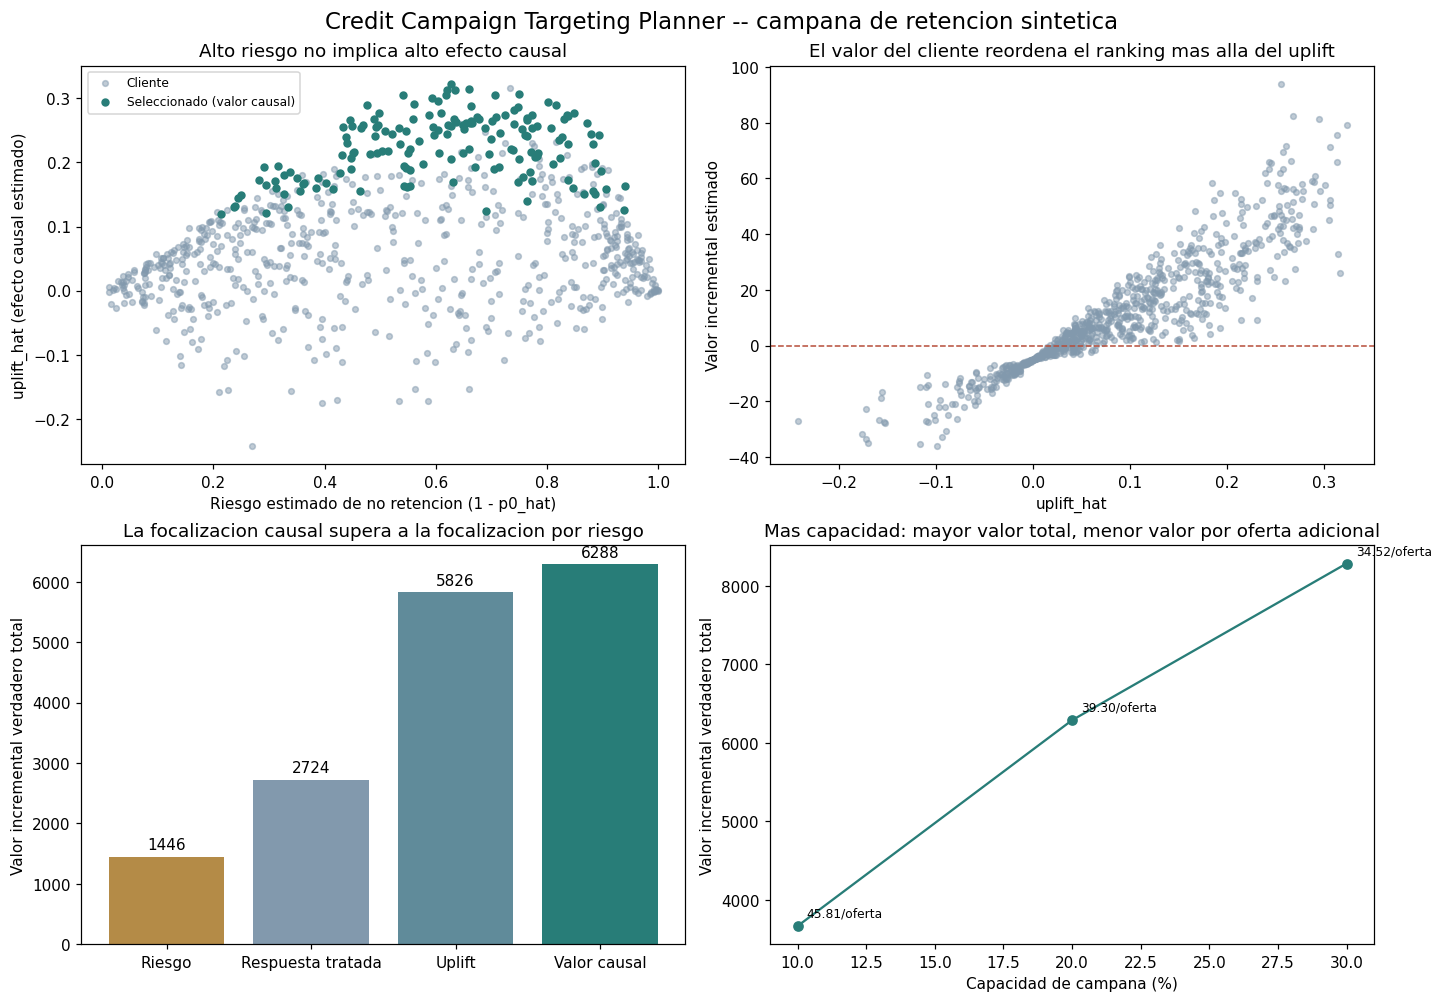

In [30]:
# El planeador completo es el producto de decision: a quien ofrecer, por que y cuanto valor genera.

planner.suptitle("Credit Campaign Targeting Planner -- campana de retencion sintetica", fontsize=15)
display(planner)

In [31]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert len(campaign) == 2000 and campaign.customer_id.is_unique
assert len(train) == 1200 and len(test) == 800
assert set(train.customer_id) & set(test.customer_id) == set()
assert FEATURES == [
    "tenure_months", "recent_transactions", "recent_spend",
    "digital_engagement", "digital_engagement_squared",
    "months_since_last_purchase", "annual_fee",
]
assert "customer_value" not in FEATURES
assert not ({"true_p0", "true_p1", "true_uplift"} & set(FEATURES))
assert K == 160
assert len(policy_A) == K
assert len(policy_D) == K
assert policy_D == policy_sets["causal_value"]
assert (
    targeting_decisions.set_index("customer_id").loc[list(policy_D), "incremental_value_hat"] > 0
).all()
assert np.isclose(uplift_correlation, 0.720, atol=0.02)
assert uplift_correlation_raw < uplift_correlation
pc = policy_comparison.set_index("policy")
assert (
    pc.loc["risk", "true_total_incremental_value"]
    < pc.loc["treated_response", "true_total_incremental_value"]
    < pc.loc["uplift", "true_total_incremental_value"]
    < pc.loc["causal_value", "true_total_incremental_value"]
)
assert (capacity_sensitivity.actual_targeted == [80, 160, 240]).all()
assert capacity_sensitivity.true_total_incremental_value.diff().dropna().gt(0).all()
assert capacity_sensitivity.true_value_per_offer.diff().dropna().lt(0).all()
print("Verificado: separacion de datos, T-learner, politicas congeladas y sensibilidad de capacidad consistentes.")

Verificado: separacion de datos, T-learner, politicas congeladas y sensibilidad de capacidad consistentes.


In [32]:
# Guardamos las decisiones de focalizacion, la comparacion de politicas, la sensibilidad y el planeador.

submission_dir.mkdir(exist_ok=True)
targeting_decisions.to_csv(submission_dir / "targeting_decisions.csv", index=False)
policy_comparison.to_csv(submission_dir / "policy_comparison.csv", index=False)
capacity_sensitivity.to_csv(submission_dir / "capacity_sensitivity.csv", index=False)
planner.savefig(
    submission_dir / "credit_campaign_targeting_planner.png", dpi=180, bbox_inches="tight", facecolor="white"
)
display(
    [
        str(submission_dir / name)
        for name in [
            "targeting_decisions.csv",
            "policy_comparison.csv",
            "capacity_sensitivity.csv",
            "credit_campaign_targeting_planner.png",
        ]
    ]
)

['../submission/targeting_decisions.csv',
 '../submission/policy_comparison.csv',
 '../submission/capacity_sensitivity.csv',
 '../submission/credit_campaign_targeting_planner.png']